In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd 

df = pd.read_csv("../co2.csv")


In [5]:
X = df[['Engine Size(L)', 'Cylinders', 'Fuel Consumption City (L/100 km)', 
        'Fuel Consumption Hwy (L/100 km)', 'Fuel Consumption Comb (L/100 km)', 
        'Fuel Consumption Comb (mpg)']].values
y = df[['CO2 Emissions(g/km)']].values
   


In [7]:
ones = np.ones((X.shape[0],1))
X_b = np.hstack((ones,X))

In [25]:
# Compute Theta using Normal Equation: θ = (Xᵗ X)⁻¹ Xᵗ y
X_transpose = X_b.T
theta = np.linalg.inv(X_transpose.dot(X_b)).dot(X_transpose).dot(y)
np.save('model_weights.npy', theta)

In [9]:
# Print Theta Vector
print("Theta (Intercept and Coefficients):")
print(theta)


Theta (Intercept and Coefficients):
[[ 2.27892751e+02]
 [ 4.99360380e+00]
 [ 7.53852995e+00]
 [-2.37835504e-02]
 [ 4.49061364e+00]
 [ 1.67304643e+00]
 [-3.42349241e+00]]


In [11]:
# Predict y_hat using theta
y_hat = X_b.dot(theta)
print(y_hat)

[[199.13137746]
 [221.12283474]
 [136.98347218]
 ...
 [231.17317105]
 [222.32167533]
 [235.70305163]]


In [17]:
#error calculation 
n = len(y)
error_sum = 0 
for actual,predicted in zip(y,y_hat):
    error = actual - predicted 
    error_squared = error**2
    error_sum = error_sum + error_squared
mse = error_sum/n
print(f"Mean Squared Error (MSE): {mse.item()}")  


Mean Squared Error (MSE): 328.9536829263451


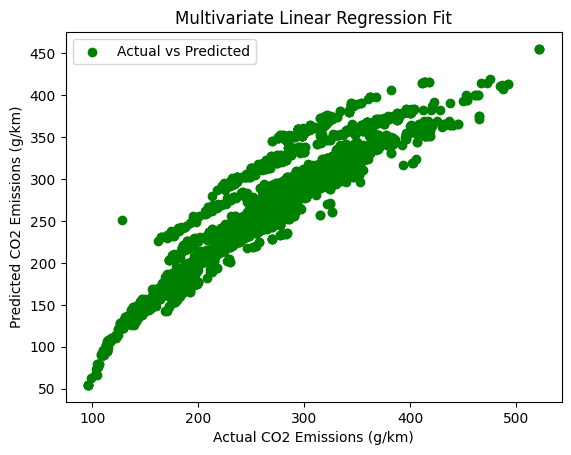

In [24]:
# Plot Actual vs Predicted CO2 Emissions
plt.scatter(y, y_hat, color="green", label="Actual vs Predicted")
plt.xlabel("Actual CO2 Emissions (g/km)")
plt.ylabel("Predicted CO2 Emissions (g/km)")
plt.title("Multivariate Linear Regression Fit")
plt.legend()
plt.show()